In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

plt.style.use('default')

def save_simple_tex(df, filename, caption, label):
    df_out = df.copy()
    def fmt(x):
        if isinstance(x, (float, np.floating)):
            if abs(x) < 1e-10: return "0.0000"
            if abs(x) < 0.001: return "{:.2e}".format(x)
            return "{:.4f}".format(x)
        return x
    df_out = df_out.applymap(fmt)
    
    new_cols = [str(c).replace("Transformation", "Trans").replace("Correlation", "Corr")
                 .replace("Intercept", "Int").replace("Slope", "Slp") for c in df_out.columns]
    df_out.columns = new_cols

    df_out.to_latex(
        filename, index=True, caption=caption, label=label,
        position="H", column_format="l" + "c"*len(df_out.columns), escape=False
    )
    print(f"[OK] Zapisano: {filename}")

data = pd.read_csv('CH03PR15.txt', sep=r'\s+', header=None, names=['Intensity', 'Time'])
data = data.sort_values(by='Time') 

X = data['Time']
y = data['Intensity']
n = len(y)

/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_6381/1404472971.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


[OK] Zapisano: zad4_lin_params.tex
----------------------------------------
WYNIKI MODELU LINIOWEGO:
R-squared (R^2): 0.8116
Korelacja:       0.9009
----------------------------------------
[OK] Zapisano: zad4_lin_stats.tex
[OK] Wykres liniowy zapisany.


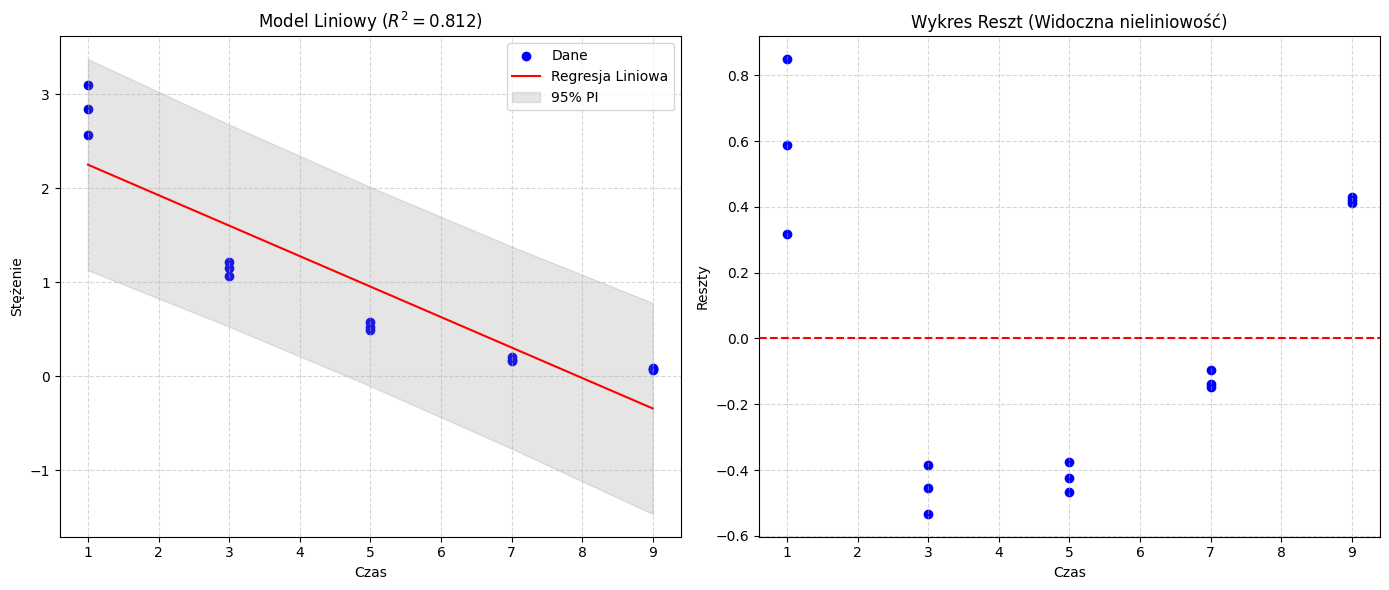

In [33]:
X_const = sm.add_constant(X)
model_lin = sm.OLS(y, X_const).fit()

df_lin_params = pd.DataFrame({
    'Coef': model_lin.params.values,
    'SE': model_lin.bse.values,
    't': model_lin.tvalues.values,
    'P-val': model_lin.pvalues.values
}, index=['Intercept', 'Time'])

save_simple_tex(df_lin_params, 'zad4_lin_params.tex', 'Parametry modelu liniowego', 'tab:zad4_lin')

r2_linear = model_lin.rsquared 
y_pred = model_lin.fittedvalues
corr_lin = np.corrcoef(y, y_pred)[0, 1]

print("-" * 40)
print(f"WYNIKI MODELU LINIOWEGO:")
print(f"R-squared (R^2): {r2_linear:.4f}")  
print(f"Korelacja:       {corr_lin:.4f}")
print("-" * 40)

df_lin_stats = pd.DataFrame({
    'R-squared': [r2_linear],
    'Correlation': [corr_lin],
    'F-stat': [model_lin.fvalue],
    'P-val (F)': [model_lin.f_pvalue]
}, index=['Model Liniowy'])

save_simple_tex(df_lin_stats, 'zad4_lin_stats.tex', 'Statystyki dopasowania modelu liniowego', 'tab:zad4_lin_stats')

pred_lin = model_lin.get_prediction(X_const).summary_frame(alpha=0.05)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(X, y, color='blue', label='Dane')
ax[0].plot(X, pred_lin['mean'], color='red', label='Regresja Liniowa')
ax[0].fill_between(X, pred_lin['obs_ci_lower'], pred_lin['obs_ci_upper'], color='gray', alpha=0.2, label='95% PI')
ax[0].set_title(f'Model Liniowy ($R^2={r2_linear:.3f}$)') 
ax[0].set_xlabel('Czas')
ax[0].set_ylabel('Stężenie')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

residuals = model_lin.resid
ax[1].scatter(X, residuals, color='blue')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Wykres Reszt (Widoczna nieliniowość)')
ax[1].set_xlabel('Czas')
ax[1].set_ylabel('Reszty')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('zad4_wykres_lin.png')
print("[OK] Wykres liniowy zapisany.")
plt.show()

[OK] Zapisano: zad4_boxcox_compare.tex
Manual: 0.0220, Scipy: 0.0205
[OK] Zapisano wykres Box-Cox.


<>:35: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:35: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_6381/779861248.py:35: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.xlabel('Lambda ($\lambda$)')
/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_6381/1404472971.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


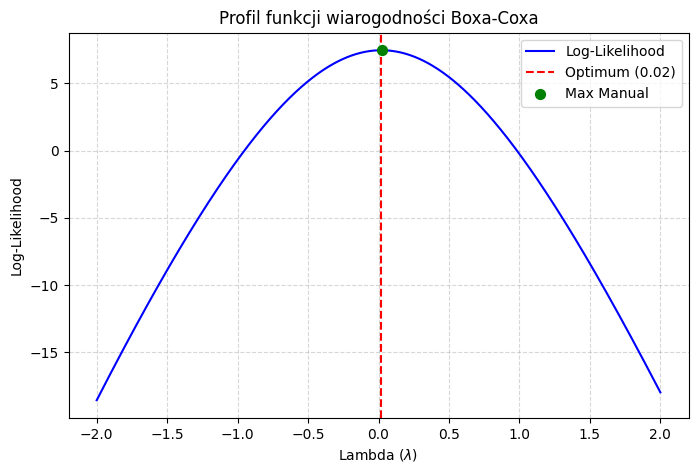

In [34]:
y_trans_scipy, lambda_opt_scipy = stats.boxcox(y)

def manual_log_likelihood(lmbda, data):
    n = len(data)

    if abs(lmbda) < 1e-9:
        y_t = np.log(data)
    else:
        y_t = (data**lmbda - 1) / lmbda
    
    var_t = np.var(y_t)
    
    ll = -(n / 2.0) * np.log(var_t) + (lmbda - 1) * np.sum(np.log(data))
    return ll

lambdas = np.linspace(-2, 2, 1000)
ll_values = [manual_log_likelihood(l, y) for l in lambdas]
lambda_opt_manual = lambdas[np.argmax(ll_values)]

df_bc_comp = pd.DataFrame({
    'Metoda': ['Manualna', 'Biblioteczna '],
    'Znalezione Lambda': [lambda_opt_manual, lambda_opt_scipy]
}).set_index('Metoda')

save_simple_tex(df_bc_comp, 'zad4_boxcox_compare.tex', 'Porównanie optymalnego parametru Lambda', 'tab:bc_comp')

print(f"Manual: {lambda_opt_manual:.4f}, Scipy: {lambda_opt_scipy:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(lambdas, ll_values, label='Log-Likelihood', color='blue')
plt.axvline(lambda_opt_scipy, color='red', linestyle='--', label=f'Optimum ({lambda_opt_scipy:.2f})')
plt.scatter(lambda_opt_manual, np.max(ll_values), color='green', s=50, zorder=5, label='Max Manual')

plt.title('Profil funkcji wiarogodności Boxa-Coxa')
plt.xlabel('Lambda ($\lambda$)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('zad4_boxcox.png')
print("[OK] Zapisano wykres Box-Cox.")
plt.show()

/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_6381/1404472971.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


[OK] Zapisano: zad4_log_stats.tex
[OK] Wykres logarytmiczny zapisany.


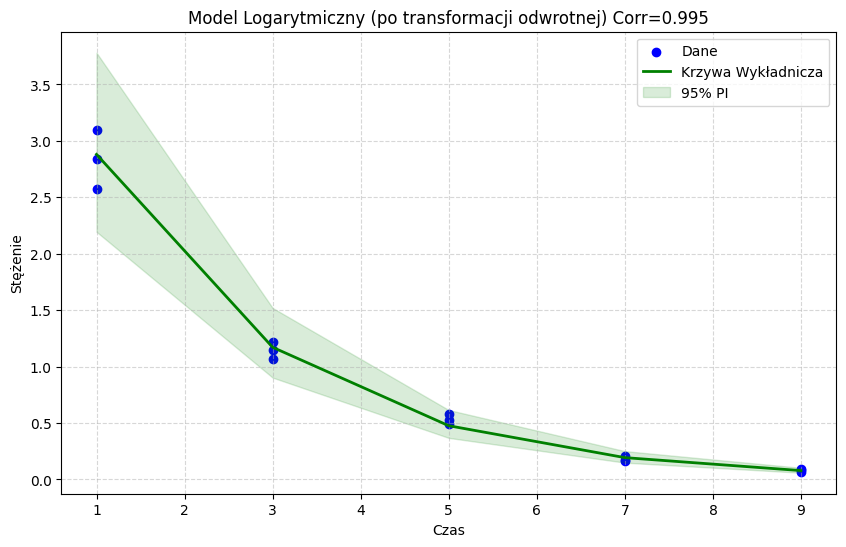

In [35]:
y_log = np.log(y)

model_log = sm.OLS(y_log, X_const).fit()

pred_log = model_log.get_prediction(X_const).summary_frame(alpha=0.05)

y_pred_back = np.exp(pred_log['mean'])
pi_low_back = np.exp(pred_log['obs_ci_lower'])
pi_high_back = np.exp(pred_log['obs_ci_upper'])

corr_log_back = np.corrcoef(y, y_pred_back)[0, 1]

df_log_stats = pd.DataFrame({
    'R-squared (log scale)': [model_log.rsquared],
    'Correlation (orig scale)': [corr_log_back],
    'Lambda used': [0.0] 
}, index=['Model Log (ln Y)'])

save_simple_tex(df_log_stats, 'zad4_log_stats.tex', 'Statystyki modelu logarytmicznego', 'tab:zad4_log')

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Dane')
plt.plot(X, y_pred_back, color='green', linewidth=2, label='Krzywa Wykładnicza')
plt.fill_between(X, pi_low_back, pi_high_back, color='green', alpha=0.15, label='95% PI')

plt.title(f'Model Logarytmiczny (po transformacji odwrotnej) Corr={corr_log_back:.3f}')
plt.xlabel('Czas')
plt.ylabel('Stężenie')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('zad4_wykres_log.png')
print("[OK] Wykres logarytmiczny zapisany.")
plt.show()

/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_6381/2888619767.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'P-val': [model_trans.pvalues[1]]
/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_6381/1404472971.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


[OK] Zapisano: zad4_trans_stats.tex
[OK] Wykres transformacji X zapisany.


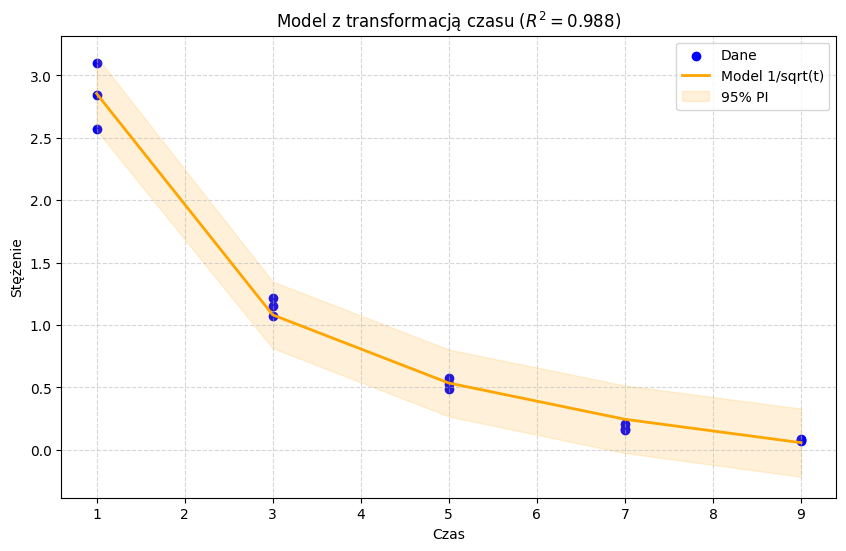

In [36]:
t_tilde = 1 / np.sqrt(X)

X_trans = sm.add_constant(t_tilde)
X_trans.columns = ['const', 'InvSqrtTime'] 

model_trans = sm.OLS(y, X_trans).fit()

y_pred_trans = model_trans.fittedvalues
corr_trans = np.corrcoef(y, y_pred_trans)[0, 1]

df_trans_stats = pd.DataFrame({
    'R-squared': [model_trans.rsquared],
    'Correlation': [corr_trans],
    'P-val': [model_trans.pvalues[1]]
}, index=['Model X-Trans'])

save_simple_tex(df_trans_stats, 'zad4_trans_stats.tex', 'Statystyki modelu z transformacją czasu (slope)', 'tab:zad4_trans')

pred_trans = model_trans.get_prediction(X_trans).summary_frame(alpha=0.05)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Dane')

sort_idx = np.argsort(X)
plt.plot(X.iloc[sort_idx], pred_trans['mean'].iloc[sort_idx], color='orange', linewidth=2, label='Model 1/sqrt(t)')
plt.fill_between(X.iloc[sort_idx], 
                 pred_trans['obs_ci_lower'].iloc[sort_idx], 
                 pred_trans['obs_ci_upper'].iloc[sort_idx], 
                 color='orange', alpha=0.15, label='95% PI')

plt.title(f'Model z transformacją czasu ($R^2={model_trans.rsquared:.3f}$)')
plt.xlabel('Czas')
plt.ylabel('Stężenie')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('zad4_wykres_trans.png')
print("[OK] Wykres transformacji X zapisany.")
plt.show()

In [37]:
models_data = [
    {
        'Model': 'Liniowy (Y ~ t)', 
        'R-squared': model_lin.rsquared, 
        'Korelacja (Orig)': corr_lin,
        'Uwagi': 'Nieliniowe reszty'
    },
    {
        'Model': 'Logarytmiczny (ln Y ~ t)', 
        'R-squared': model_log.rsquared, 
        'Korelacja (Orig)': corr_log_back,
        'Uwagi': 'Najlepsze dopasowanie'
    },
    {
        'Model': 'Transf. czasu (Y ~ 1/sqrt(t))', 
        'R-squared': model_trans.rsquared, 
        'Korelacja (Orig)': corr_trans,
        'Uwagi': 'Brak uzasadnienia fiz.'
    }
]

df_summary = pd.DataFrame(models_data).set_index('Model')

save_simple_tex(df_summary, 'zad4_summary.tex', 'Porównanie jakości dopasowania modeli', 'tab:zad4_sum')

display(df_summary)

[OK] Zapisano: zad4_summary.tex


/var/folders/95/2tlvxbjs611bfpzxmqg1gfvm0000gn/T/ipykernel_6381/1404472971.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_out = df_out.applymap(fmt)


,R-squared,Korelacja (Orig),Uwagi
Model,,,
Liniowy (Y ~ t),0.811577,0.900876,Nieliniowe reszty
Logarytmiczny (ln Y ~ t),0.992978,0.994559,Najlepsze dopasowanie
Transf. czasu (Y ~ 1/sqrt(t)),0.988063,0.994014,Brak uzasadnienia fiz.
